# Streaming catalog EDA: Netflix vs Prime Video vs Apple TV+

First look at `data/titles.csv`, the TMDB capture from `init.py`: US subscription (flatrate) titles
released or first aired in the last 5 years, labeled **in-house** (platform's own studio/network, or a
movie that premiered on the platform) vs **third-party** (licensed).

**Unit of analysis:** one row = one *platform × title*. A title on two services appears twice.

Sections
1. Setup & load
2. Data overview: shape, types, missing values
3. Catalog composition: how much is in-house?
4. Ratings: vote counts, the small-sample problem, a weighted rating
5. In-house vs third-party quality
6. Genres
7. Release timing
8. Runtime, seasons, language
9. Cross-platform overlap
10. Correlations
11. Top titles
12. Takeaways & data caveats

## 1. Setup & load

In [1]:
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:,.2f}".format)

# Chart style: recessive grid/axes, thin marks, text in ink colors (not series colors)
INK, INK_2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
plt.rcParams.update({
    "figure.figsize": (10, 4.5), "figure.dpi": 110, "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE, "axes.edgecolor": GRID, "axes.labelcolor": INK_2,
    "axes.titlecolor": INK, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": INK_2, "ytick.color": INK_2, "text.color": INK,
    "legend.frameon": False, "lines.linewidth": 2,
})

# Fixed colors: each platform always keeps the same hue (validated categorical slots 1-3)
PLATFORM_COLORS = {"Netflix": "#2a78d6", "Amazon Prime Video": "#eb6834", "Apple TV+": "#1baf7a"}
PLATFORMS = list(PLATFORM_COLORS)
# In-house vs third-party: emphasis color vs neutral gray
LABEL_COLORS = {"in_house": "#4a3aa7", "third_party": "#a8a79f"}

In [2]:
df = pd.read_csv("data/titles.csv", parse_dates=["release_date"])

# Tidy types
df["platform"] = pd.Categorical(df["platform"], categories=PLATFORMS, ordered=True)
df["in_house"] = df["label"].eq("in_house")
df["release_year"] = df["release_date"].dt.year
df["release_q"] = df["release_date"].dt.to_period("Q")

# TMDB uses 0 for "unknown" budget/revenue: treat as missing, not zero
for col in ["budget", "revenue"]:
    df[col] = df[col].replace(0, np.nan)

# Semicolon-joined lists -> Python lists (for genre / company analysis)
for col in ["genres", "production_companies", "networks", "us_flatrate_providers"]:
    df[col + "_list"] = df[col].fillna("").str.split("; ").apply(lambda xs: [x for x in xs if x])

# TMDB lists ad tiers and add-on channels as separate providers ("Netflix Standard with Ads",
# "AMC+ Amazon Channel"). Collapse them to the underlying service before counting services.
def normalize_service(name):
    name = name.strip()  # some TMDB names have trailing spaces
    name = re.sub(r"\s+(Amazon Channels?|Apple TV [Cc]hannel|Roku Premium Channel)$", "", name)
    name = re.sub(r"\s+(Standard |Basic )?with Ads$", "", name)
    name = re.sub(r"\s+(Premium Plus|Premium|Essential|Kids)$", "", name)
    return {"Paramount Plus": "Paramount+", "AMC Plus": "AMC+"}.get(name, name)

df["services"] = df["us_flatrate_providers_list"].apply(lambda xs: sorted({normalize_service(x) for x in xs}))
df["n_services"] = df["services"].str.len()
movies, tv = df[df.media_type == "movie"], df[df.media_type == "tv"]
print(f"{len(df):,} rows | {df.tmdb_id.nunique():,} unique TMDB ids | "
      f"{df.release_date.min():%Y-%m-%d} to {df.release_date.max():%Y-%m-%d}")
df.head(3)

12,450 rows | 12,362 unique TMDB ids | 2021-09-25 to 2026-10-31


,platform,media_type,tmdb_id,imdb_id,title,original_language,release_date,label,matched_on,studio_match,platform_premiere,production_companies,networks,genres,runtime,number_of_seasons,number_of_episodes,status,vote_average,vote_count,popularity,budget,revenue,us_flatrate_providers,in_house,release_year,release_q,genres_list,production_companies_list,networks_list,us_flatrate_providers_list,services,n_services
0,Netflix,movie,32471,tt1587420,Mixtape,en,2021-12-03,in_house,NaN,False,True,Maven Screen Media; Jim Wedaa Productions,NaN,Comedy; Family,94.00,NaN,NaN,Released,6.93,146,2.88,NaN,NaN,Netflix; Netflix Standard with Ads,True,2021,2021Q4,"[Comedy, Family]","[Maven Screen Media, Jim Wedaa Productions]",[],"[Netflix, Netflix Standard with Ads]",[Netflix],1
1,Netflix,movie,49046,tt1016150,All Quiet on the Western Front,de,2022-10-07,in_house,NaN,False,True,Amusement Park Films; Gunpowder Films,NaN,War; Drama,147.00,NaN,NaN,Released,7.74,4938,17.51,"20,000,000.00",NaN,Netflix; Netflix Standard with Ads,True,2022,2022Q4,"[War, Drama]","[Amusement Park Films, Gunpowder Films]",[],"[Netflix, Netflix Standard with Ads]",[Netflix],1
2,Netflix,movie,278193,tt33319697,Detective Ujjwalan,ml,2025-05-23,third_party,NaN,False,False,Weekend Blockbusters,NaN,Mystery; Crime,124.00,NaN,NaN,Released,5.73,22,0.71,NaN,NaN,Netflix; Netflix Standard with Ads,False,2025,2025Q2,"[Mystery, Crime]",[Weekend Blockbusters],[],"[Netflix, Netflix Standard with Ads]",[Netflix],1


## 2. Data overview

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12450 entries, 0 to 12449
Data columns (total 33 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   platform                    12450 non-null  category      
 1   media_type                  12450 non-null  str           
 2   tmdb_id                     12450 non-null  int64         
 3   imdb_id                     11496 non-null  str           
 4   title                       12450 non-null  str           
 5   original_language           12450 non-null  str           
 6   release_date                12450 non-null  datetime64[us]
 7   label                       12450 non-null  str           
 8   matched_on                  1947 non-null   str           
 9   studio_match                12450 non-null  bool          
 10  platform_premiere           12450 non-null  bool          
 11  production_companies        9692 non-null   str           
 12  n

In [4]:
# Missing values: which fields can we trust for which media type?
core = ["imdb_id", "production_companies", "networks", "genres", "runtime",
        "number_of_seasons", "budget", "revenue"]
missing = (df.groupby("media_type")[core]
             .apply(lambda g: g.isna().mean() * 100)
             .T.round(1).add_suffix(" % missing"))
missing

media_type,movie % missing,tv % missing
imdb_id,6.50,10.70
production_companies,23.10,19.60
networks,100.00,9.70
genres,3.30,5.40
runtime,4.70,64.30
number_of_seasons,100.00,0.00
budget,88.30,100.00
revenue,91.00,100.00


Things to note:
- **`networks`, `number_of_seasons`** are TV-only, and **`budget`/`revenue`** are movie-only (and mostly unknown). Expect NaN on the other type.
- **Budget/revenue** are unknown for most movies, which rules them out as broad features. They only cover big releases.
- **Runtime** is often missing for TV (TMDB's `episode_run_time` is frequently empty).

In [5]:
df[["vote_average", "vote_count", "popularity", "runtime", "number_of_seasons",
    "number_of_episodes", "budget", "revenue"]].describe(percentiles=[.25, .5, .75, .9, .99]).T

,count,mean,std,min,25%,50%,75%,90%,99%,max
vote_average,"12,450.00",5.11,2.80,0.00,4.00,6.00,7.00,7.88,10.00,10.00
vote_count,"12,450.00",104.08,445.40,0.00,1.00,9.00,42.00,175.10,"1,938.51","11,594.00"
popularity,"12,450.00",4.27,28.16,0.10,1.14,1.89,3.76,8.21,35.23,"2,907.31"
runtime,"9,818.00",87.15,33.80,1.00,70.00,90.00,105.00,124.00,165.00,767.00
number_of_seasons,"3,437.00",1.38,1.05,1.00,1.00,1.00,1.00,2.00,5.00,20.00
number_of_episodes,"3,437.00",13.28,20.69,1.00,6.00,8.00,14.00,25.00,88.92,446.00
budget,"1,052.00","19,414,375.20","44,517,054.61",1.00,"97,712.00","1,980,000.00","20,000,000.00","60,000,000.00","200,000,000.00","658,800,000.00"
revenue,807.00,"43,661,068.71","122,337,028.91",1.00,"282,051.50","4,000,000.00","28,898,649.00","108,077,727.60","633,217,318.02","1,488,732,821.00"


## 3. Catalog composition: how much of each catalog is in-house?

In [6]:
comp = pd.crosstab([df.platform, df.media_type], df.label, margins=True, margins_name="total")
comp["in_house_%"] = comp["in_house"] / comp["total"] * 100
comp

label                          in_house  third_party  total  in_house_%
platform           media_type                                          
Netflix            movie           1404         1124   2528       55.54
                   tv              1365          492   1857       73.51
Amazon Prime Video movie            336         6078   6414        5.24
                   tv               225         1186   1411       15.95
Apple TV+          movie             60           11     71       84.51
                   tv               168            1    169       99.41
total                              3558         8892  12450       28.58

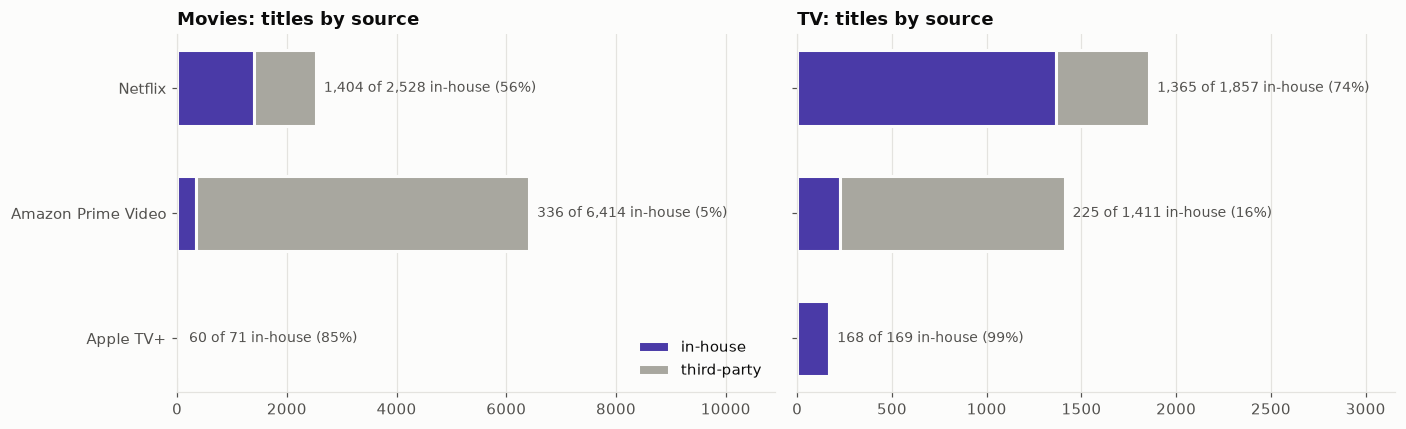

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, (media, g) in zip(axes, df.groupby("media_type")):
    counts = g.groupby(["platform", "label"], observed=True).size().unstack(fill_value=0)
    counts = counts.reindex(PLATFORMS)[["in_house", "third_party"]]
    left = np.zeros(len(counts))
    for label in counts.columns:
        ax.barh(counts.index, counts[label], left=left, color=LABEL_COLORS[label],
                edgecolor=SURFACE, linewidth=2, label=label.replace("_", "-"), height=0.6)
        left += counts[label].values
    for i, (n_in, total) in enumerate(zip(counts["in_house"], counts.sum(axis=1))):
        ax.text(total, i, f"  {n_in:,} of {total:,} in-house ({n_in / total:.0%})",
                va="center", color=INK_2, fontsize=9)
    ax.set_title(f"{'Movies' if media == 'movie' else 'TV'}: titles by source")
    ax.grid(axis="y", visible=False)
    ax.set_xlim(0, counts.sum(axis=1).max() * 1.7)
axes[0].invert_yaxis()  # shared y-axis: invert once
axes[0].legend(loc="lower right")
plt.tight_layout()

**Read:** Netflix and Apple TV+ are mostly originals in TV. Apple TV+ is almost *entirely* in-house.
Prime Video's catalog is much bigger but mostly licensed, especially movies.

How each in-house label was assigned (studio credit vs premiere-date rule). The premiere rule also
catches acquired "Originals" (e.g. festival pickups), so use `studio_match` if you want *produced by*:

In [8]:
pd.crosstab([df.platform, df.media_type], [df.studio_match, df.platform_premiere])

studio_match                  False       True       
platform_premiere             False True  False True 
platform           media_type                        
Netflix            movie       1124  1379     0    25
                   tv           492     0  1365     0
Amazon Prime Video movie       6078   189    45   102
                   tv          1186     0   225     0
Apple TV+          movie         11    43     3    14
                   tv             1     0   168     0

## 4. Ratings: vote counts first

`vote_average` is only meaningful with enough votes. How many votes do titles actually have?

% of titles with vote_count,> 0,>= 10,>= 50,>= 100,>= 500,>= 1000
platform,,,,,,
Netflix,95.20,74.70,40.90,27.20,8.10,3.80
Amazon Prime Video,74.40,32.30,11.90,7.30,1.90,1.00
Apple TV+,100.00,85.00,55.00,43.30,17.50,8.30


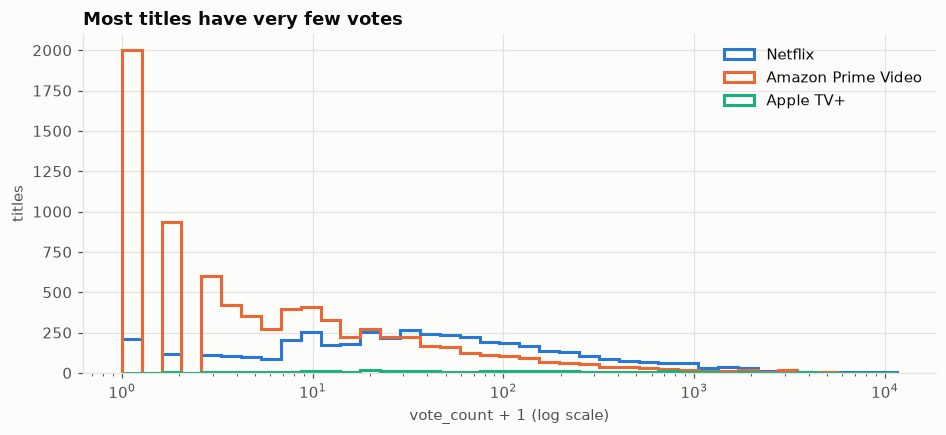

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
bins = np.logspace(0, np.log10(df.vote_count.max() + 1), 40)
for p in PLATFORMS:
    ax.hist(df.loc[df.platform == p, "vote_count"] + 1, bins=bins, histtype="step",
            linewidth=2, color=PLATFORM_COLORS[p], label=p)
ax.set_xscale("log")
ax.set_xlabel("vote_count + 1 (log scale)"); ax.set_ylabel("titles")
ax.set_title("Most titles have very few votes")
ax.legend()

thresholds = [0, 10, 50, 100, 500, 1000]
share = pd.DataFrame({f">= {t}" if t else "> 0": (df.groupby("platform", observed=True).vote_count
                      .apply(lambda s: (s > t).mean() if t == 0 else (s >= t).mean()) * 100)
                      for t in thresholds}).round(1)
share.columns.name = "% of titles with vote_count"
share

Most titles have fewer than 50 votes, and a 9.5 from 3 votes is noise. Two ways to handle it:
1. **Filter** to `vote_count >= MIN_VOTES` when comparing averages.
2. **Weighted (Bayesian) rating** (the IMDb Top-250 formula), which shrinks low-vote titles toward the global mean:

$$WR = \frac{v}{v+m}R + \frac{m}{v+m}C$$

where *R* = title's average, *v* = its votes, *m* = minimum-votes prior, *C* = mean rating across titles.

In [10]:
MIN_VOTES = 50  # try 20 / 100 and see what changes

rated = df[df.vote_count >= MIN_VOTES].copy()
C = rated.vote_average.mean()
m = rated.vote_count.quantile(0.5)
df["weighted_rating"] = (df.vote_count / (df.vote_count + m) * df.vote_average
                         + m / (df.vote_count + m) * C)
rated["weighted_rating"] = df.loc[rated.index, "weighted_rating"]
print(f"{len(rated):,} rows with >= {MIN_VOTES} votes | C (mean rating) = {C:.2f} | m = {m:.0f}")

2,855 rows with >= 50 votes | C (mean rating) = 6.80 | m = 144


count  mean  50%  std
platform           media_type                         
Netflix            movie      1,111.00  6.59 6.59 0.72
                   tv           684.00  7.39 7.40 0.74
Amazon Prime Video movie        761.00  6.36 6.34 0.82
                   tv           167.00  7.52 7.50 0.69
Apple TV+          movie         50.00  6.92 6.88 0.71
                   tv            82.00  7.15 7.23 0.63

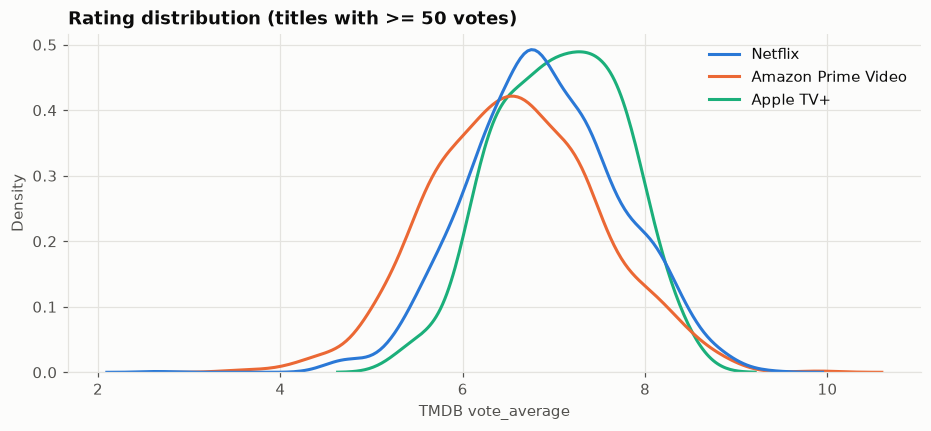

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.kdeplot(data=rated, x="vote_average", hue="platform", hue_order=PLATFORMS,
            palette=PLATFORM_COLORS, common_norm=False, linewidth=2, ax=ax)
ax.set_title(f"Rating distribution (titles with >= {MIN_VOTES} votes)")
ax.set_xlabel("TMDB vote_average"); ax.get_legend().set_title(None)
rated.groupby(["platform", "media_type"], observed=True).vote_average.describe()[["count", "mean", "50%", "std"]]

## 5. In-house vs third-party: are originals rated better?

In [12]:
summary = (rated.groupby(["platform", "media_type", "label"], observed=True)
                .agg(n=("vote_average", "size"), mean_rating=("vote_average", "mean"),
                     median_rating=("vote_average", "median"),
                     median_votes=("vote_count", "median"),
                     median_popularity=("popularity", "median"))
                .unstack("label"))
summary

n             mean_rating             median_rating             median_votes             median_popularity            
label                         in_house third_party    in_house third_party      in_house third_party     in_house third_party          in_house third_party
platform           media_type                                                                                                                              
Netflix            movie           789         322        6.56        6.66          6.55        6.67       187.00      172.50              4.50        4.69
                   tv              546         138        7.27        7.84          7.30        8.06       114.50      118.50              7.66       13.16
Amazon Prime Video movie           164         597        6.48        6.33          6.49        6.32       207.50      113.00              5.84        3.73
                   tv               79          88        7.32        7.69          7.24        7.77       158.00      107.00             13.06        9.67
Apple TV+          movie            43           7        6.88        7.12          6.85        7.08       653.00      255.00             11.40        8.98
                   tv               81           1        7.14        7.46          7.21        7.46       183.00       73.00             16.83        5.96

Text(0.02, 1.04, 'In-house vs third-party ratings (>= 50 votes)')

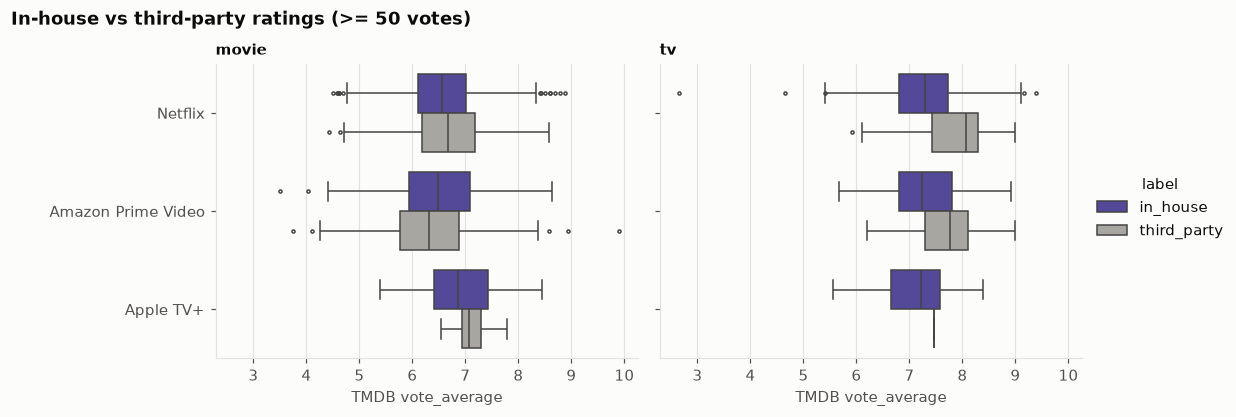

In [13]:
g = sns.catplot(data=rated, x="vote_average", y="platform", hue="label", col="media_type",
                kind="box", order=PLATFORMS, hue_order=["in_house", "third_party"],
                palette=LABEL_COLORS, height=3.6, aspect=1.4, fliersize=2, linewidth=1)
g.set_titles("{col_name}"); g.set_axis_labels("TMDB vote_average", "")
g.fig.suptitle(f"In-house vs third-party ratings (>= {MIN_VOTES} votes)", x=0.02, ha="left", y=1.04,
               fontweight="bold")

In [14]:
# Mann-Whitney U (non-parametric; ratings are skewed & bounded) per platform x media type
rows = []
for (p, mt), g in rated.groupby(["platform", "media_type"], observed=True):
    a, b = g.loc[g.in_house, "vote_average"], g.loc[~g.in_house, "vote_average"]
    if min(len(a), len(b)) < 10:
        rows.append((p, mt, len(a), len(b), np.nan, np.nan, np.nan)); continue
    u, pval = stats.mannwhitneyu(a, b, alternative="two-sided")
    rows.append((p, mt, len(a), len(b), a.median() - b.median(), u / (len(a) * len(b)), pval))
pd.DataFrame(rows, columns=["platform", "media_type", "n_in_house", "n_third_party",
                            "median_diff (in - 3rd)", "P(in > 3rd)", "p_value"])

,platform,media_type,n_in_house,n_third_party,median_diff (in - 3rd),P(in > 3rd),p_value
0,Netflix,movie,789,322,-0.12,0.46,0.03
1,Netflix,tv,546,138,-0.76,0.27,0.00
2,Amazon Prime Video,movie,164,597,0.17,0.56,0.02
3,Amazon Prime Video,tv,79,88,-0.52,0.34,0.00
4,Apple TV+,movie,43,7,NaN,NaN,NaN
5,Apple TV+,tv,81,1,NaN,NaN,NaN


`P(in > 3rd)` is the common-language effect size: the probability a random in-house title outrates a
random third-party one (0.5 = no difference). Groups with < 10 titles are skipped (Apple third-party
TV has almost none).

⚠️ Confounders: licensed catalogs skew toward different genres, languages and ages. Popular licensed titles
also attract more votes. Treat this as descriptive, not causal.

## 6. Genres

In [15]:
genres = df.explode("genres_list").dropna(subset=["genres_list"]).rename(columns={"genres_list": "genre"})
top_genres = genres.genre.value_counts()
top_genres.head(20).to_frame("titles")

,titles
genre,
Drama,4581
Comedy,3358
Documentary,2152
Thriller,1850
Crime,1405
Horror,1341
Romance,1221
Action,1197
Mystery,882


Text(77.91666666666666, 0.5, '')

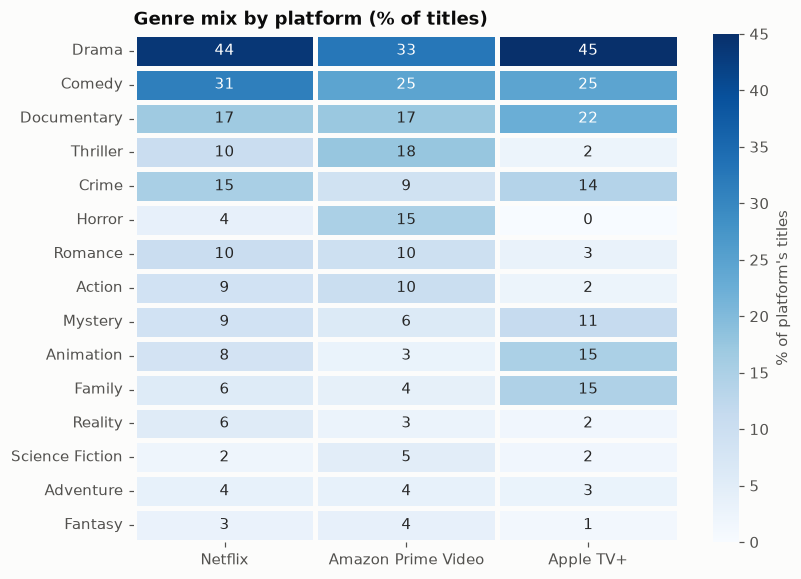

In [16]:
# Share of each platform's catalog in each genre (a title can have several genres, so columns sum to >100%)
genre_share = (genres.groupby(["genre", "platform"], observed=True).tmdb_id.size()
                     .unstack() / df.groupby("platform", observed=True).size() * 100)
genre_share = genre_share.loc[top_genres.index[:15]].fillna(0)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(genre_share, annot=True, fmt=".0f", cmap="Blues", cbar_kws={"label": "% of platform's titles"},
            linewidths=2, linecolor=SURFACE, ax=ax)
ax.set_title("Genre mix by platform (% of titles)"); ax.set_xlabel(""); ax.set_ylabel("")

In [17]:
# Which genres do platforms make in-house vs license?
genre_inhouse = (genres.groupby(["genre", "platform"], observed=True)
                       .agg(n=("in_house", "size"), in_house_pct=("in_house", "mean")))
genre_inhouse["in_house_pct"] *= 100
genre_inhouse.query("n >= 30").in_house_pct.unstack().loc[lambda t: t.index.isin(top_genres.index[:15])].round(0)

platform,Netflix,Amazon Prime Video,Apple TV+
genre,,,
Action,47.00,8.00,NaN
Adventure,61.00,8.00,NaN
Animation,63.00,7.00,100.00
Comedy,62.00,9.00,93.00
Crime,73.00,9.00,97.00
Documentary,80.00,8.00,91.00
Drama,56.00,8.00,95.00
Family,59.00,6.00,97.00
Fantasy,64.00,6.00,NaN


## 7. Release timing

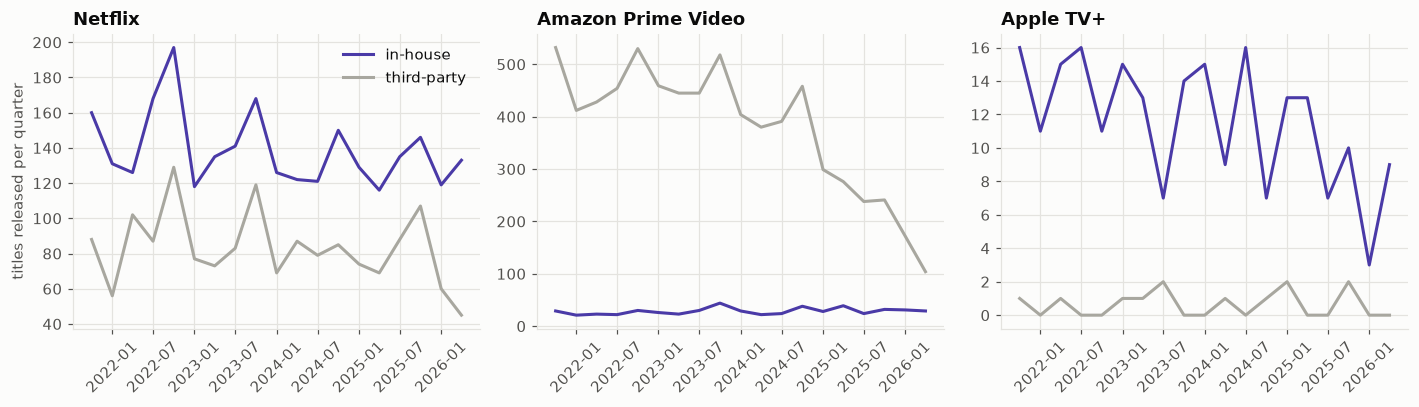

In [18]:
now = pd.Timestamp.today().to_period("Q")
first_full = (df.release_date.min() - pd.Timedelta(days=1)).to_period("Q") + 1
by_q = (df[(df.release_q >= first_full) & (df.release_q < now)]  # full quarters only
          .groupby(["release_q", "platform", "label"], observed=True).size().rename("titles").reset_index())
by_q["release_q"] = by_q["release_q"].dt.to_timestamp()

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=False)
for ax, p in zip(axes, PLATFORMS):
    g = by_q[by_q.platform == p].pivot(index="release_q", columns="label", values="titles").fillna(0)
    for label in ["in_house", "third_party"]:
        if label in g:
            ax.plot(g.index, g[label], color=LABEL_COLORS[label], label=label.replace("_", "-"))
    ax.set_title(p); ax.tick_params(axis="x", rotation=45)
axes[0].set_ylabel("titles released per quarter"); axes[0].legend()
plt.tight_layout()

Note that recent quarters look thin partly because **licensed titles arrive on streamers months or years
after release**. The newest third-party titles aren't on the platforms yet (right-censoring), so a
downward trend at the right edge is not necessarily real.

## 8. Runtime, seasons, language

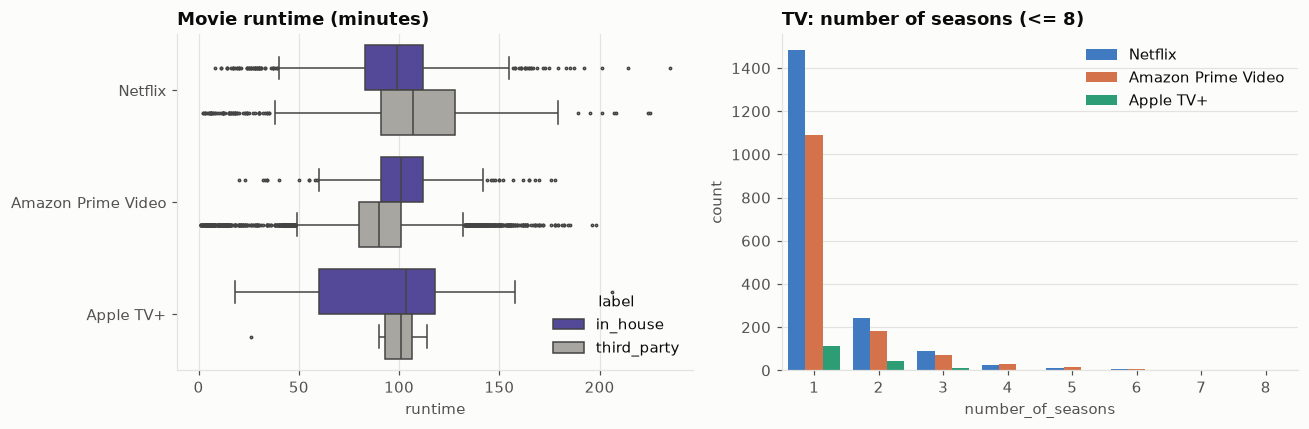

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=movies[movies.runtime.between(1, 300)], x="runtime", y="platform", hue="label",
            order=PLATFORMS, hue_order=["in_house", "third_party"], palette=LABEL_COLORS,
            fliersize=1.5, linewidth=1, ax=axes[0])
axes[0].set_title("Movie runtime (minutes)"); axes[0].set_ylabel("")
sns.countplot(data=tv[tv.number_of_seasons <= 8].astype({"number_of_seasons": int}), x="number_of_seasons", hue="platform",
              hue_order=PLATFORMS, palette=PLATFORM_COLORS, ax=axes[1])
axes[1].set_title("TV: number of seasons (<= 8)"); axes[1].get_legend().set_title(None)
plt.tight_layout()

In [20]:
# Top original languages per platform (% of titles)
lang = (df.groupby("platform", observed=True).original_language
          .value_counts(normalize=True).mul(100).rename("pct").reset_index())
lang.pivot(index="original_language", columns="platform", values="pct").fillna(0) \
    .loc[lambda t: t.max(axis=1) >= 2].sort_values("Netflix", ascending=False).round(1)

platform,Netflix,Amazon Prime Video,Apple TV+
original_language,,,
en,42.00,73.60,93.80
es,8.60,4.50,2.90
ja,6.80,2.40,0.00
ko,5.90,1.60,0.40
hi,5.10,1.80,0.00
id,2.60,0.50,0.00
fr,2.50,2.40,1.70
th,2.40,0.40,0.00
pt,2.40,1.20,0.00


## 9. Cross-platform overlap: how exclusive are catalogs?

,titles on 2+ of our platforms
platform,
Amazon Prime Video & Netflix,86
Amazon Prime Video & Apple TV+,2


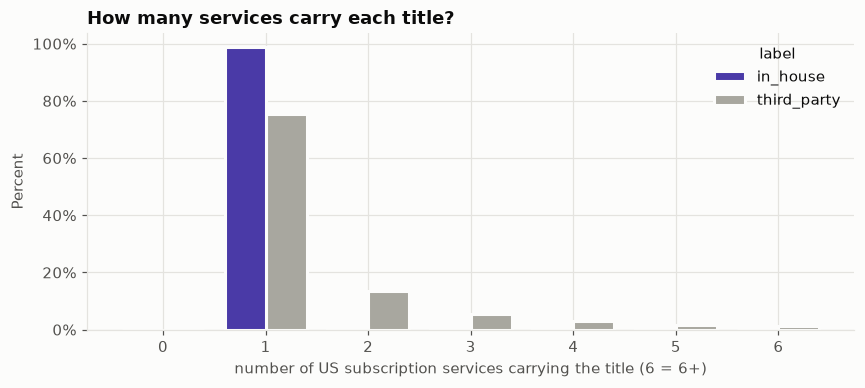

In [21]:
# Using each title's full US subscription list (normalized services, not just our 3 platforms)
fig, ax = plt.subplots(figsize=(9, 3.5))
sns.histplot(data=df, x=df.n_services.clip(upper=6), hue="label", hue_order=["in_house", "third_party"],
             palette=LABEL_COLORS, multiple="dodge", discrete=True, shrink=0.8, stat="percent",
             common_norm=False, edgecolor=SURFACE, linewidth=2, alpha=1, ax=ax)
ax.set_xlabel("number of US subscription services carrying the title (6 = 6+)")
ax.set_title("How many services carry each title?")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# Titles in our dataset on more than one of the three platforms
on = df.groupby(["media_type", "tmdb_id"]).platform.agg(lambda s: " & ".join(sorted(s.astype(str))))
n_on = df.groupby(["media_type", "tmdb_id"]).size()
on[n_on > 1].value_counts().to_frame("titles on 2+ of our platforms")

In [22]:
# Which other services show up most alongside third-party titles?
own = {"Netflix": "Netflix", "Amazon Prime Video": "Amazon Prime Video", "Apple TV+": "Apple TV"}
others = df[~df.in_house].explode("services")
others = others[others.services != others.platform.astype(str).map(own)]
(others.groupby("platform", observed=True).services.value_counts()
       .groupby(level=0, group_keys=False).head(8).to_frame("third-party titles also on"))

third-party titles also on
platform           services                                      
Netflix            Amazon Prime Video                          74
                   Philo                                       58
                   Hulu                                        47
                   YouTube TV                                  31
                   fuboTV                                      30
                   Crunchyroll                                 29
                   Paramount+                                  25
                   Rakuten Viki                                24
Amazon Prime Video fuboTV                                     398
                   Philo                                      385
                   Cineverse                                  232
                   Screambox                                  143
                   Dove                                       129
                   UP Faith & Family                          125
                   Peacock                                    111
                   Bloodstream                                106

## 10. Correlations between numeric metrics

Text(0.0, 1.0, 'Spearman correlations (titles with >= 50 votes)')

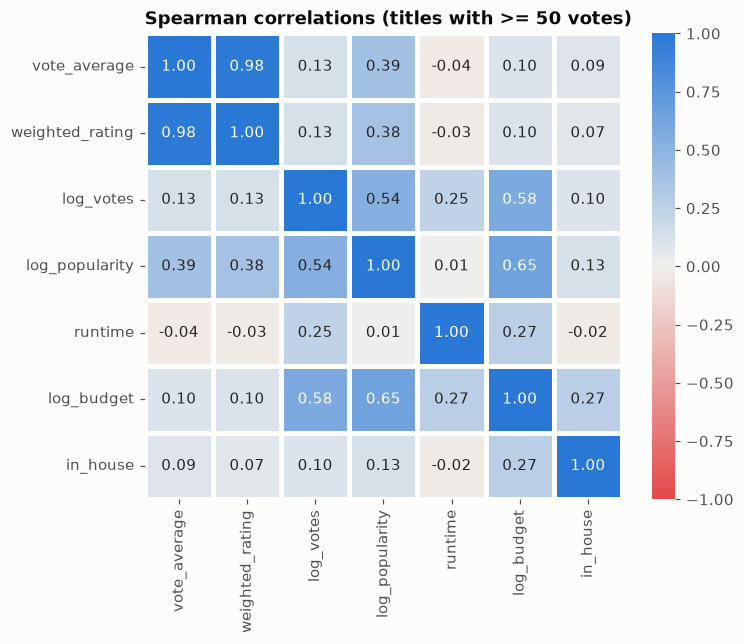

In [23]:
num = rated.assign(log_votes=np.log10(rated.vote_count), log_popularity=np.log10(rated.popularity + 0.01),
                   log_budget=np.log10(rated.budget))
cols = ["vote_average", "weighted_rating", "log_votes", "log_popularity", "runtime", "log_budget", "in_house"]
corr = num[cols].astype(float).corr(method="spearman")

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=sns.blend_palette(["#e34948", "#f0efec", "#2a78d6"], as_cmap=True),
            vmin=-1, vmax=1, center=0, linewidths=2, linecolor=SURFACE, ax=ax)
ax.set_title(f"Spearman correlations (titles with >= {MIN_VOTES} votes)")

Spearman (rank) correlation is used because votes, popularity and budget are heavily skewed. Popularity is
TMDB's *current* trending score, which favors new releases and says little about lasting quality.

## 11. Top titles by weighted rating

In [24]:
TOP_N = 10
cols = ["title", "media_type", "label", "release_date", "vote_average", "vote_count", "weighted_rating", "genres"]
for p in PLATFORMS:
    print(f"\n=== {p} ===")
    display(df[df.platform == p].nlargest(TOP_N, "weighted_rating")[cols]
              .assign(release_date=lambda t: t.release_date.dt.date))


=== Netflix ===


,title,media_type,label,release_date,vote_average,vote_count,weighted_rating,genres
3940,Teach You a Lesson,tv,in_house,2026-06-05,9.39,928,9.04,Action & Adventure; Drama; Comedy
876,Swapped,movie,in_house,2026-05-01,8.87,2200,8.74,Adventure; Animation; Family; Fantasy
2543,Arcane,tv,in_house,2021-11-06,8.75,6186,8.70,Animation; Action & Adventure; Sci-Fi & Fantasy
3074,Frieren: Beyond Journey's End,tv,third_party,2023-09-29,8.81,971,8.55,Animation; Action & Adventure; Drama; Sci-Fi &...
2418,Facing El Chapo,movie,in_house,2026-08-21,8.79,794,8.49,Crime; Action; Thriller
2616,Heartstopper,tv,in_house,2022-04-22,8.56,1774,8.43,Drama
3258,When Life Gives You Tangerines,tv,in_house,2025-03-07,8.81,590,8.41,Drama
2558,Cyberpunk: Edgerunners,tv,in_house,2022-09-13,8.48,1978,8.37,Animation; Action & Adventure; Sci-Fi & Fantas...
2703,Alchemy of Souls,tv,third_party,2022-06-18,8.58,819,8.31,Drama; Sci-Fi & Fantasy; Action & Adventure; M...
2596,Wednesday,tv,in_house,2022-11-23,8.33,10833,8.31,Sci-Fi & Fantasy; Mystery; Comedy



=== Amazon Prime Video ===


,title,media_type,label,release_date,vote_average,vote_count,weighted_rating,genres
4598,Project Hail Mary,movie,in_house,2026-03-15,8.64,7943,8.61,Science Fiction; Adventure
11830,Off Campus,tv,in_house,2026-05-13,8.91,861,8.60,Drama
10802,Hazbin Hotel,tv,third_party,2024-01-18,8.54,1659,8.40,Animation; Comedy; Drama; Sci-Fi & Fantasy
6159,The Way to the Heart,movie,third_party,2024-04-02,9.90,143,8.34,Drama; Comedy
8201,The Wild Robot,movie,third_party,2024-09-12,8.30,6632,8.27,Family; Animation; Science Fiction; Adventure
11772,No One Will Miss Us,tv,in_house,2024-08-09,8.77,382,8.23,Drama; Comedy
11288,Marry My Husband,tv,third_party,2024-01-01,8.50,718,8.21,Drama; Sci-Fi & Fantasy; Comedy
11261,Spider-Noir,tv,in_house,2026-05-25,8.35,858,8.13,Drama; Mystery; Crime
11234,Death's Game,tv,third_party,2023-12-15,8.40,668,8.12,Drama; Sci-Fi & Fantasy
10819,Reacher,tv,in_house,2022-02-03,8.13,3396,8.07,Action & Adventure; Crime



=== Apple TV+ ===


,title,media_type,label,release_date,vote_average,vote_count,weighted_rating,genres
12285,Severance,tv,in_house,2022-02-17,8.39,2976,8.32,Drama; Mystery; Sci-Fi & Fantasy
12311,Silo,tv,in_house,2023-05-04,8.22,2718,8.15,Sci-Fi & Fantasy; Drama
12246,Selena Gomez: My Mind & Me,movie,in_house,2022-11-04,8.45,620,8.14,Documentary; Music
12244,"The Boy, the Mole, the Fox and the Horse",movie,in_house,2022-12-25,8.20,774,7.98,Animation; Family; Drama; Adventure
12283,Prehistoric Planet,tv,in_house,2022-05-23,8.30,520,7.98,Documentary
12334,Black Bird,tv,in_house,2022-07-07,8.07,1079,7.92,Drama; Crime
12286,Slow Horses,tv,in_house,2022-04-01,8.03,997,7.87,Crime; Drama; Mystery
12301,Lessons in Chemistry,tv,in_house,2023-10-12,8.18,427,7.83,Drama
12259,Mayday,movie,in_house,2026-09-03,8.00,780,7.81,Action; Comedy
12432,Widow's Bay,tv,in_house,2026-04-28,8.10,489,7.80,Drama; Comedy; Mystery


## 12. Takeaways & caveats

Fill these in as you go. Things to verify:
- [ ] In-house share per platform/media type (section 3)
- [ ] Do originals rate higher? Size of effect and which platform (section 5)
- [ ] Genre strategy differences: what each platform builds vs buys (section 6)

**Data caveats to carry into any write-up**
- **Snapshot:** TMDB watch-provider data reflects *today's* US availability, not historical catalogs.
- **Label rule:** in-house = studio/network credit **or** premiere on platform within 90 days of first US
  release (movies). The premiere rule counts acquired films as "originals".
- **Prime Video's "amazon" substring match** also catches Freevee / MGM+ -branded companies. Inspect `matched_on`.
- **Low vote counts:** most titles have < 50 votes. Always filter or use `weighted_rating`.
- **Right-censoring:** recent licensed titles aren't on streamers yet.
- **Double counting:** titles on several platforms appear once per platform. Dedupe on (`media_type`, `tmdb_id`)
  for title-level stats.